# Treino do Modelo PyTorch (GRU Bidirecional)
Este notebook treina um GRU bidirecional com embeddings aprendidos para classificação multi-classe de texto (Human vs. AI).

In [13]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import pickle
import re
import os
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from collections import Counter
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    balanced_accuracy_score, accuracy_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.makedirs("plots", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 1. Pré-processamento e Construção do Vocabulário

In [14]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return text.split()

def build_vocab(texts, max_words=5000):
    counter = Counter()
    for t in texts:
        counter.update(clean_text(t))
    vocab = {"<pad>": 0, "<unk>": 1}
    for i, (word, _) in enumerate(counter.most_common(max_words - 2), start=2):
        vocab[word] = i
    return vocab

def encode(text, vocab, max_len=100):
    ids = [vocab.get(token, vocab["<unk>"]) for token in clean_text(text)][:max_len]
    if len(ids) < max_len:
        ids += [vocab["<pad>"]] * (max_len - len(ids))
    return ids

## 2. Carregamento dos Dados

In [15]:
df = pd.read_csv("data/dataset-exemplos.csv", sep=";")

# O pickle do notebook 1 guardou a classe NeuralNetworkTracked (definida inline).
# É necessário registá-la aqui antes do load para evitar AttributeError.
import sys
from src.neuralnet import NeuralNetwork
class NeuralNetworkTracked(NeuralNetwork):
    pass
sys.modules["__main__"].NeuralNetworkTracked = NeuralNetworkTracked

# Usar o mesmo LabelEncoder do modelo NumPy para consistência
with open("modelo_numpy_artefactos.pkl", "rb") as f:
    artefactos_np = pickle.load(f)
le = artefactos_np["label_encoder"]

df = df[df["Label"].isin(le.classes_)].copy()
labels_idx = le.transform(df["Label"])

vocab = build_vocab(df["Text"].values)

print(f"Exemplos válidos: {len(df)}")
print(f"Vocabulário: {len(vocab)} palavras")
print(f"Classes: {le.classes_}")

Exemplos válidos: 102
Vocabulário: 2796 palavras
Classes: ['Google' 'Human' 'Meta' 'Mistral' 'OpenAI']


## 3. Dataset e DataLoaders (Train/Validation/Test)

In [16]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=100):
        self.texts  = texts
        self.labels = labels
        self.vocab  = vocab
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        x = encode(self.texts[idx], self.vocab, self.max_len)
        return torch.tensor(x, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

full_dataset = TextDataset(df["Text"].values, labels_idx, vocab)
n_total  = len(full_dataset)
n_test   = max(1, int(0.15 * n_total))
n_val    = max(1, int(0.15 * n_total))
n_train  = n_total - n_test - n_val

generator = torch.Generator().manual_seed(RANDOM_SEED)
train_ds, val_ds, test_ds = random_split(full_dataset, [n_train, n_val, n_test], generator=generator)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

print(f"Train: {n_train} | Val: {n_val} | Test: {n_test}")

Train: 72 | Val: 15 | Test: 15


## 4. Definição do Modelo GRU

In [17]:
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(
            embed_dim, hidden_dim,
            num_layers=2, batch_first=True,
            bidirectional=True, dropout=0.3
        )
        self.fc      = nn.Linear(hidden_dim * 2, num_classes)
        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        embedded = self.embedding(x)
        _, hidden = self.gru(embedded)
        # Concatenar últimas hidden states (frente + trás)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(self.dropout(hidden))

model = GRUClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=128,
    num_classes=len(le.classes_)
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parâmetros treináveis: {total_params:,}")
print(model)

Parâmetros treináveis: 853,765
GRUClassifier(
  (embedding): Embedding(2796, 128, padding_idx=0)
  (gru): GRU(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Linear(in_features=256, out_features=5, bias=True)
  (dropout): Dropout(p=0.4, inplace=False)
)


## 5. Treino com Validação por Época

In [18]:
criterion   = nn.CrossEntropyLoss()
optimizer_pt = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler   = optim.lr_scheduler.ReduceLROnPlateau(optimizer_pt, patience=3, factor=0.5)

EPOCHS = 30
best_val_loss = float('inf')

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

def evaluate_loader(loader, model, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out  = model(x)
            total_loss += criterion(out, y).item()
            correct    += (out.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / len(loader), correct / total

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer_pt.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer_pt.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == y).sum().item()
        total      += y.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc  = correct / total
    val_loss, val_acc = evaluate_loader(val_loader, model, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "modelo_pytorch_gru.pth")

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

with open("pytorch_vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)
print("\nMelhor modelo PyTorch guardado com sucesso!")

Epoch   1/30 | Train Loss: 1.5529 Acc: 0.3472 | Val Loss: 1.4759 Acc: 0.4667
Epoch   5/30 | Train Loss: 0.7102 Acc: 0.7917 | Val Loss: 1.3651 Acc: 0.4667
Epoch  10/30 | Train Loss: 0.1799 Acc: 0.9722 | Val Loss: 1.6116 Acc: 0.4667
Epoch  15/30 | Train Loss: 0.0792 Acc: 1.0000 | Val Loss: 1.8200 Acc: 0.4667
Epoch  20/30 | Train Loss: 0.0611 Acc: 0.9861 | Val Loss: 1.8657 Acc: 0.4667
Epoch  25/30 | Train Loss: 0.0572 Acc: 0.9861 | Val Loss: 1.8941 Acc: 0.4667
Epoch  30/30 | Train Loss: 0.0443 Acc: 1.0000 | Val Loss: 1.9019 Acc: 0.4667

Melhor modelo PyTorch guardado com sucesso!


## 6. Curvas de Treino e Validação

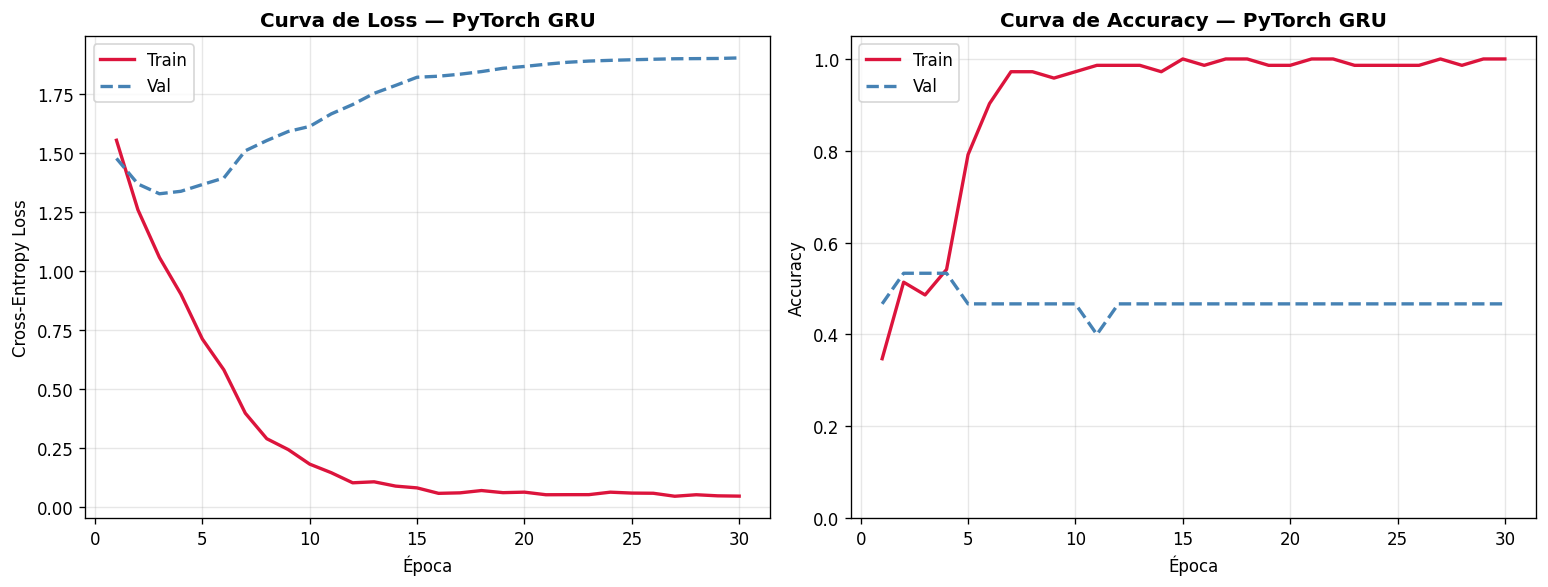

In [19]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train", color="crimson", linewidth=2)
axes[0].plot(epochs_range, history["val_loss"],   label="Val",   color="steelblue", linewidth=2, linestyle="--")
axes[0].set_title("Curva de Loss — PyTorch GRU", fontweight='bold')
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train", color="crimson", linewidth=2)
axes[1].plot(epochs_range, history["val_acc"],   label="Val",   color="steelblue", linewidth=2, linestyle="--")
axes[1].set_title("Curva de Accuracy — PyTorch GRU", fontweight='bold')
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plots/pytorch_training_curves.png", bbox_inches='tight')
plt.show()

## 7. Avaliação no Conjunto de Teste

In [20]:
# Carregar melhor modelo
model.load_state_dict(torch.load("modelo_pytorch_gru.pth", map_location=device))
model.eval()

all_preds, all_labels = [], []
test_total_loss = 0.0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out  = model(x)
        test_total_loss += criterion(out, y).item()
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
test_loss_pt = test_total_loss / len(test_loader)

# Lista de índices de todas as classes (evita erro quando alguma classe não aparece nas preds)
all_class_indices = list(range(len(le.classes_)))

# Métricas
test_acc_pt        = accuracy_score(all_labels, all_preds)
macro_f1_pt        = f1_score(all_labels, all_preds, average="macro",    labels=all_class_indices, zero_division=0)
weighted_f1_pt     = f1_score(all_labels, all_preds, average="weighted", labels=all_class_indices, zero_division=0)
macro_precision_pt = precision_score(all_labels, all_preds, average="macro", labels=all_class_indices, zero_division=0)
macro_recall_pt    = recall_score(all_labels, all_preds, average="macro",    labels=all_class_indices, zero_division=0)
bal_acc_pt         = balanced_accuracy_score(all_labels, all_preds)

print("=" * 55)
print("       AVALIAÇÃO NO CONJUNTO DE TESTE - PyTorch GRU")
print("=" * 55)
print(f"  Test Loss              : {test_loss_pt:.4f}")
print(f"  Test Accuracy          : {test_acc_pt:.4f}")
print(f"  Balanced Accuracy      : {bal_acc_pt:.4f}")
print(f"  Macro F1-Score         : {macro_f1_pt:.4f}")
print(f"  Weighted F1-Score      : {weighted_f1_pt:.4f}")
print(f"  Macro Precision        : {macro_precision_pt:.4f}")
print(f"  Macro Recall           : {macro_recall_pt:.4f}")
print("=" * 55)

print("\nRelatório por Classe:")
print(classification_report(
    all_labels, all_preds,
    labels=all_class_indices,
    target_names=le.classes_,
    zero_division=0
))

       AVALIAÇÃO NO CONJUNTO DE TESTE - PyTorch GRU
  Test Loss              : 1.2089
  Test Accuracy          : 0.6667
  Balanced Accuracy      : 0.2500
  Macro F1-Score         : 0.1600
  Weighted F1-Score      : 0.5333
  Macro Precision        : 0.1333
  Macro Recall           : 0.2000

Relatório por Classe:
              precision    recall  f1-score   support

      Google       0.00      0.00      0.00         2
       Human       0.67      1.00      0.80        10
        Meta       0.00      0.00      0.00         1
     Mistral       0.00      0.00      0.00         0
      OpenAI       0.00      0.00      0.00         2

    accuracy                           0.67        15
   macro avg       0.13      0.20      0.16        15
weighted avg       0.44      0.67      0.53        15



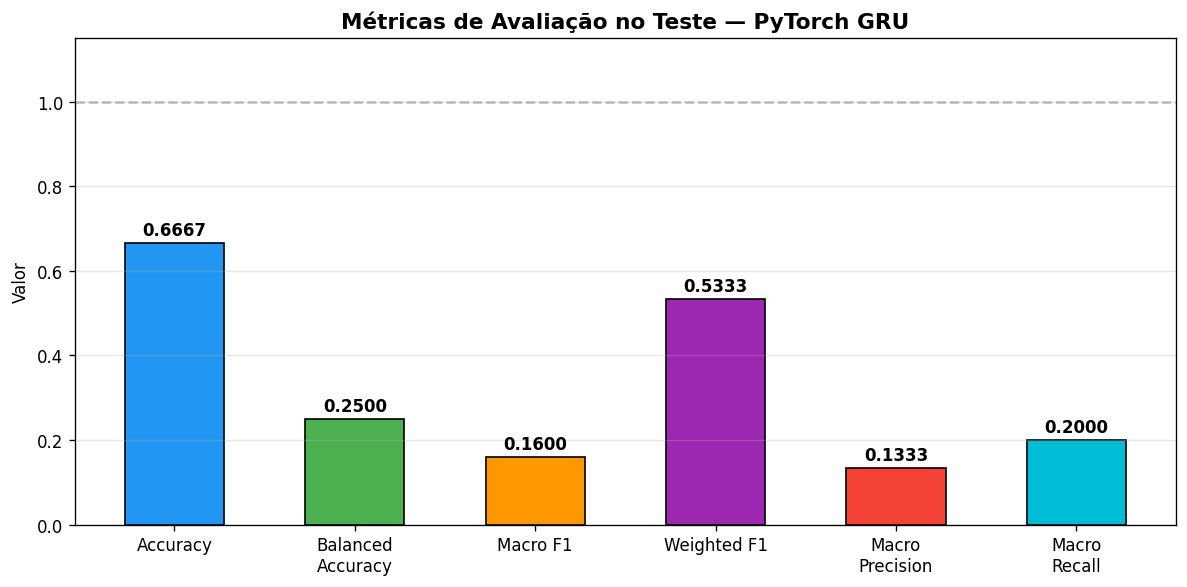

In [21]:
# Gráfico de barras das métricas
metrics_names  = ["Accuracy", "Balanced\nAccuracy", "Macro F1", "Weighted F1", "Macro\nPrecision", "Macro\nRecall"]
metrics_values = [test_acc_pt, bal_acc_pt, macro_f1_pt, weighted_f1_pt, macro_precision_pt, macro_recall_pt]
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(metrics_names, metrics_values, color=colors, edgecolor='black', width=0.55)
for bar, val in zip(bars, metrics_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.4f}", ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_title("Métricas de Avaliação no Teste — PyTorch GRU", fontsize=13, fontweight='bold')
ax.set_ylabel("Valor")
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("plots/pytorch_test_metrics.png", bbox_inches='tight')
plt.show()

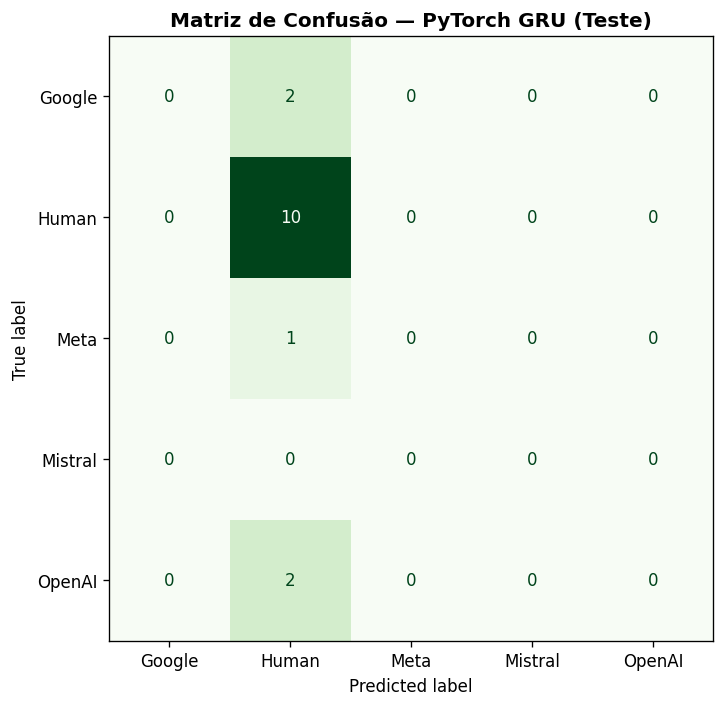

In [22]:
# Matriz de Confusão
cm_pt = confusion_matrix(all_labels, all_preds, labels=all_class_indices)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pt, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title("Matriz de Confusão — PyTorch GRU (Teste)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("plots/pytorch_confusion_matrix.png", bbox_inches='tight')
plt.show()

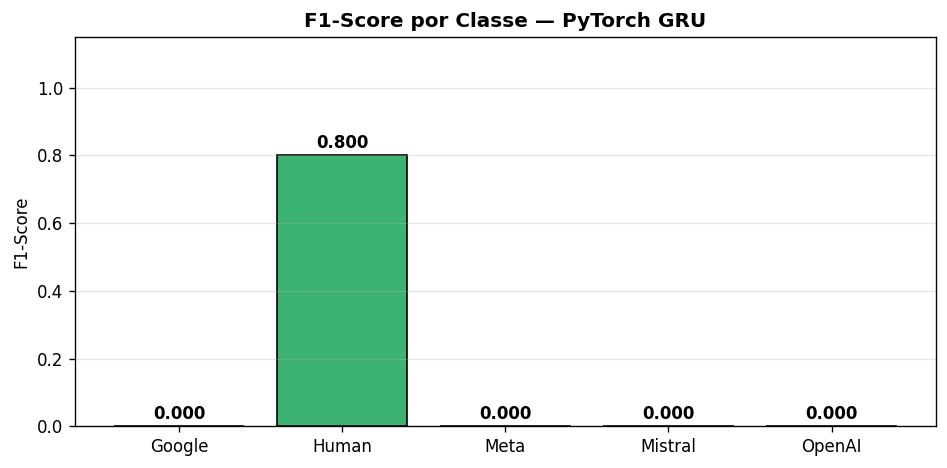


Resumo Final — PyTorch GRU:
  Macro F1   : 0.1600
  Accuracy   : 0.6667
  Bal. Acc   : 0.2500


In [23]:
# F1-Score por classe
f1_per_class_pt = f1_score(all_labels, all_preds, average=None, labels=all_class_indices, zero_division=0)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(le.classes_, f1_per_class_pt, color='mediumseagreen', edgecolor='black')
for bar, val in zip(bars, f1_per_class_pt):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_title("F1-Score por Classe — PyTorch GRU", fontsize=12, fontweight='bold')
ax.set_ylabel("F1-Score")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("plots/pytorch_f1_per_class.png", bbox_inches='tight')
plt.show()

# Guardar métricas PyTorch
pytorch_metrics = {
    "test_loss": test_loss_pt,
    "test_accuracy": test_acc_pt,
    "balanced_accuracy": bal_acc_pt,
    "macro_f1": macro_f1_pt,
    "weighted_f1": weighted_f1_pt,
    "macro_precision": macro_precision_pt,
    "macro_recall": macro_recall_pt,
    "history": history
}
with open("pytorch_metrics.pkl", "wb") as f:
    pickle.dump(pytorch_metrics, f)

print(f"\nResumo Final — PyTorch GRU:")
print(f"  Macro F1   : {macro_f1_pt:.4f}")
print(f"  Accuracy   : {test_acc_pt:.4f}")
print(f"  Bal. Acc   : {bal_acc_pt:.4f}")